In [1]:
import os

import cv2

import random

import warnings

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

warnings.filterwarnings("ignore")

In [7]:

IMAGE_PATH = "ISBI2016_ISIC_Part1_Training_Data"

MASK_PATH = "ISBI2016_ISIC_Part1_Training_GroundTruth"

print("\n")
print("="*70)
print("Dataset Loaded Successfully")
print("="*70)



Dataset Loaded Successfully


In [8]:
image_files = sorted(

    os.listdir(

        IMAGE_PATH

    )

)

mask_files = sorted(

    os.listdir(

        MASK_PATH

    )

)

print("\n")
print("="*70)
print("Dataset Information")
print("="*70)

print(

    "Images :", len(image_files)

)

print(

    "Masks :", len(mask_files)

)




Dataset Information
Images : 900
Masks : 900


In [9]:
summary = pd.DataFrame({

    "Parameter":[

        "Dataset",

        "Task",

        "Images",

        "Masks"

    ],

    "Value":[

        "ISIC 2016",

        "Skin Lesion Segmentation",

        len(image_files),

        len(mask_files)

    ]

})

display(summary)


,Parameter,Value
0,Dataset,ISIC 2016
1,Task,Skin Lesion Segmentation
2,Images,900
3,Masks,900


In [10]:
print("\n")
print("="*70)
print("Dataset Verification")
print("="*70)

if len(image_files) == len(mask_files):

    print("✓ Images and Masks Matched")

else:

    print("✗ Images and Masks Count Mismatch")



Dataset Verification
✓ Images and Masks Matched


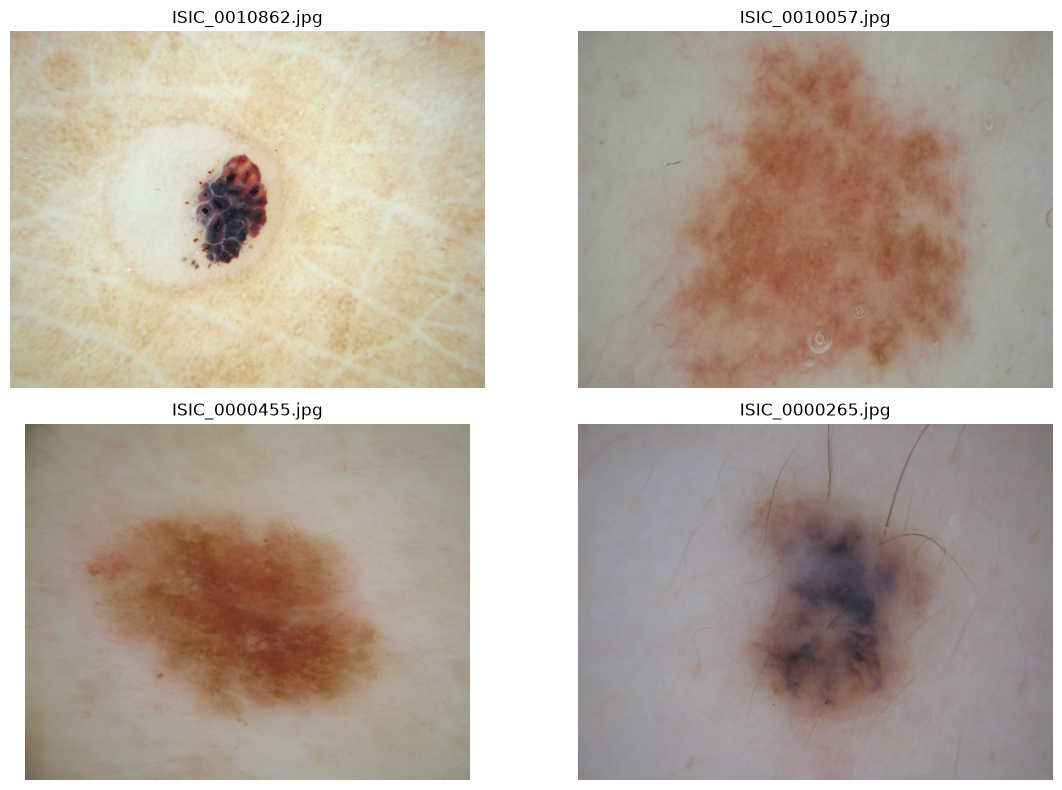

In [11]:
sample_indices = random.sample(

    range(

        len(image_files)

    ),

    4

)

plt.figure(

    figsize=(12,8)

)

for i, idx in enumerate(sample_indices):

    img = cv2.imread(

        os.path.join(

            IMAGE_PATH,

            image_files[idx]

        )

    )

    img = cv2.cvtColor(

        img,

        cv2.COLOR_BGR2RGB

    )

    plt.subplot(

        2,

        2,

        i+1

    )

    plt.imshow(

        img

    )

    plt.title(

        image_files[idx]

    )

    plt.axis("off")

plt.tight_layout()

plt.show()


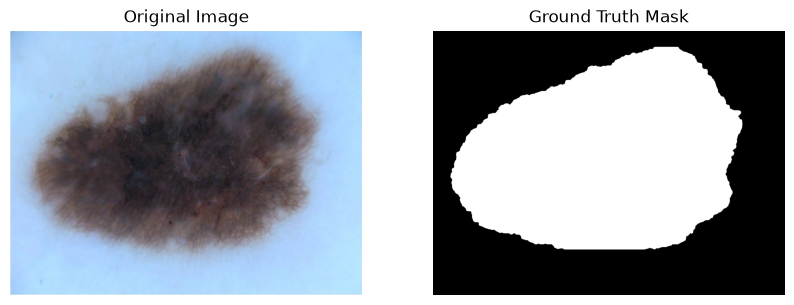

In [12]:
sample_image = image_files[0]

mask_name = sample_image.replace(

    ".jpg",

    "_Segmentation.png"

)

image = cv2.imread(

    os.path.join(

        IMAGE_PATH,

        sample_image

    )

)

image = cv2.cvtColor(

    image,

    cv2.COLOR_BGR2RGB

)

mask = cv2.imread(

    os.path.join(

        MASK_PATH,

        mask_name

    ),

    cv2.IMREAD_GRAYSCALE

)

plt.figure(

    figsize=(10,5)

)

plt.subplot(

    1,

    2,

    1

)

plt.imshow(

    image

)

plt.title("Original Image")

plt.axis("off")

plt.subplot(

    1,

    2,

    2

)

plt.imshow(

    mask,

    cmap="gray"

)

plt.title("Ground Truth Mask")

plt.axis("off")

plt.show()


In [13]:
heights = []

widths = []

for file in image_files[:100]:

    img = cv2.imread(

        os.path.join(

            IMAGE_PATH,

            file

        )

    )

    h, w, _ = img.shape

    heights.append(h)

    widths.append(w)

print("\n")
print("="*70)
print("Image Resolution Statistics")
print("="*70)

print(

    "Average Height :",

    round(

        np.mean(

            heights

        ),

        2

    )

)

print(

    "Average Width :",

    round(

        np.mean(

            widths

        ),

        2

    )

)

print(

    "Minimum Height :",

    min(

        heights

    )

)

print(

    "Maximum Height :",

    max(

        heights

    )

)

print(

    "Minimum Width :",

    min(

        widths

    )

)

print(

    "Maximum Width :",

    max(

        widths

    )

)




Image Resolution Statistics
Average Height : 1288.6
Average Width : 1717.51
Minimum Height : 722
Maximum Height : 2112
Minimum Width : 962
Maximum Width : 2816


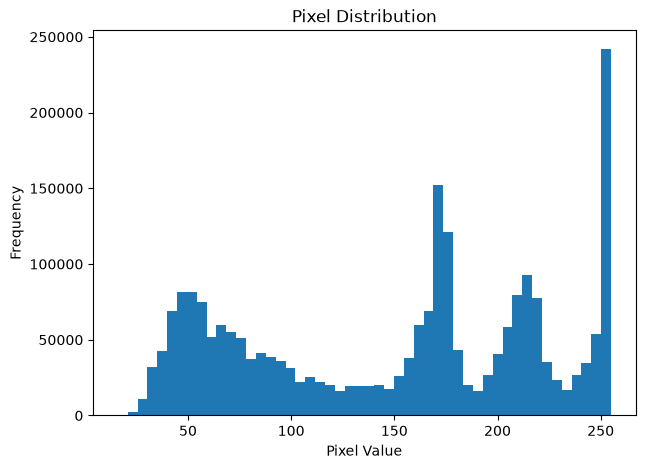

In [14]:
plt.figure(

    figsize=(7,5)

)

plt.hist(

    image.ravel(),

    bins=50

)

plt.title(

    "Pixel Distribution"

)

plt.xlabel(

    "Pixel Value"

)

plt.ylabel(

    "Frequency"

)

plt.show()


In [15]:
unique_pixels = np.unique(

    mask

)

print("\n")
print("="*70)
print("Mask Pixel Values")
print("="*70)

print(

    unique_pixels

)




Mask Pixel Values
[  0 255]


In [16]:
print("\n")
print("="*70)
print("Image Shape")
print("="*70)

print(

    image.shape

)

print(

    mask.shape

)




Image Shape
(767, 1022, 3)
(767, 1022)


In [17]:
dataset_info = pd.DataFrame({

    "Parameter":[

        "Model",

        "Problem Type",

        "Classes",

        "Recommended Image Size",

        "Epochs",

        "Batch Size"

    ],

    "Value":[

        "Lightweight U-Net",

        "Binary Segmentation",

        2,

        "128 x 128",

        10,

        8

    ]

})

display(dataset_info)


,Parameter,Value
0,Model,Lightweight U-Net
1,Problem Type,Binary Segmentation
2,Classes,2
3,Recommended Image Size,128 x 128
4,Epochs,10
5,Batch Size,8


In [18]:
import os

import cv2

import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [19]:
IMAGE_SIZE = 128

BATCH_SIZE = 8

print("\n")
print("="*70)
print("Configuration")
print("="*70)
print("Image Size :", IMAGE_SIZE)
print("Batch Size :", BATCH_SIZE)



Configuration
Image Size : 128
Batch Size : 8


In [20]:
images = []

masks = []

for image_name in sorted(os.listdir(IMAGE_PATH)):

    image_path = os.path.join(

        IMAGE_PATH,

        image_name

    )

    mask_name = image_name.replace(

        ".jpg",

        "_Segmentation.png"

    )

    mask_path = os.path.join(

        MASK_PATH,

        mask_name

    )

    if not os.path.exists(mask_path):

        continue

    # Image

    image = cv2.imread(image_path)

    image = cv2.cvtColor(

        image,

        cv2.COLOR_BGR2RGB

    )

    image = cv2.resize(

        image,

        (IMAGE_SIZE, IMAGE_SIZE)

    )

    image = image.astype(

        np.float32

    ) / 255.0

    # Mask

    mask = cv2.imread(

        mask_path,

        cv2.IMREAD_GRAYSCALE

    )

    mask = cv2.resize(

        mask,

        (IMAGE_SIZE, IMAGE_SIZE),

        interpolation=cv2.INTER_NEAREST

    )

    mask = mask.astype(

        np.float32

    ) / 255.0

    mask = np.expand_dims(

        mask,

        axis=-1

    )

    images.append(image)

    masks.append(mask)


In [21]:
images = np.array(

    images,

    dtype=np.float32

)

masks = np.array(

    masks,

    dtype=np.float32

)

print("\n")
print("="*70)
print("Dataset Loaded")
print("="*70)
print("Images :", images.shape)
print("Masks  :", masks.shape)




Dataset Loaded
Images : (900, 128, 128, 3)
Masks  : (900, 128, 128, 1)


In [22]:
X_train, X_valid, y_train, y_valid = train_test_split(

    images,

    masks,

    test_size=0.20,

    random_state=42,

    shuffle=True

)

print("\n")
print("="*70)
print("Dataset Split")
print("="*70)

print("Training Images :", X_train.shape)

print("Validation Images :", X_valid.shape)




Dataset Split
Training Images : (720, 128, 128, 3)
Validation Images : (180, 128, 128, 3)


In [23]:
print("\n")
print("="*70)
print("Pixel Verification")
print("="*70)

print("Image Min :", X_train.min())

print("Image Max :", X_train.max())

print("Mask Min :", y_train.min())

print("Mask Max :", y_train.max())



Pixel Verification
Image Min : 0.0
Image Max : 1.0
Mask Min : 0.0
Mask Max : 1.0


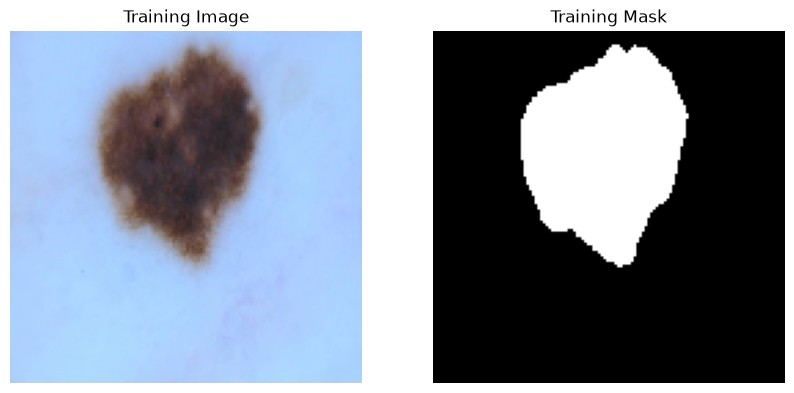

In [24]:
index = 0

plt.figure(

    figsize=(10,5)

)

plt.subplot(

    1,

    2,

    1

)

plt.imshow(

    X_train[index]

)

plt.title(

    "Training Image"

)

plt.axis("off")

plt.subplot(

    1,

    2,

    2

)

plt.imshow(

    y_train[index].squeeze(),

    cmap="gray"

)

plt.title(

    "Training Mask"

)

plt.axis("off")

plt.show()


In [25]:
print("\n")
print("="*70)
print("Dataset Information")
print("="*70)

print("Training Samples :", len(X_train))

print("Validation Samples :", len(X_valid))

print("Image Shape :", X_train.shape[1:])

print("Mask Shape :", y_train.shape[1:])

print("Batch Size :", BATCH_SIZE)

print("Image Size :", IMAGE_SIZE)




Dataset Information
Training Samples : 720
Validation Samples : 180
Image Shape : (128, 128, 3)
Mask Shape : (128, 128, 1)
Batch Size : 8
Image Size : 128


In [26]:
import tensorflow as tf

train_dataset = tf.data.Dataset.from_tensor_slices(

    (X_train, y_train)

)

train_dataset = train_dataset.batch(

    BATCH_SIZE

).prefetch(

    tf.data.AUTOTUNE

)

validation_dataset = tf.data.Dataset.from_tensor_slices(

    (X_valid, y_valid)

)

validation_dataset = validation_dataset.batch(

    BATCH_SIZE

).prefetch(

    tf.data.AUTOTUNE

)

print("\n")
print("="*70)
print("TensorFlow Dataset Created Successfully")
print("="*70)




TensorFlow Dataset Created Successfully


In [27]:
print("\n")
print("="*70)
print("Dataset Ready for Lightweight U-Net")
print("="*70)




Dataset Ready for Lightweight U-Net


In [36]:
import tensorflow as tf

from tensorflow.keras.layers import Input

from tensorflow.keras.layers import Conv2D

from tensorflow.keras.layers import MaxPooling2D

from tensorflow.keras.layers import Conv2DTranspose

from tensorflow.keras.layers import Concatenate

from tensorflow.keras.layers import Dropout

from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.callbacks import ModelCheckpoint

from tensorflow.keras.callbacks import ReduceLROnPlateau

import matplotlib.pyplot as plt

import numpy as np


In [37]:
def dice_coefficient(y_true, y_pred):

    smooth = 1e-6

    y_true = tf.keras.backend.flatten(y_true)

    y_pred = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true * y_pred)

    return (

        2. * intersection + smooth

    ) / (

        tf.reduce_sum(y_true)

        + tf.reduce_sum(y_pred)

        + smooth

    )


In [39]:
def iou_score(y_true, y_pred):

    y_pred = tf.cast(

        y_pred > 0.5,

        tf.float32

    )

    intersection = tf.reduce_sum(

        y_true * y_pred

    )

    union = tf.reduce_sum(

        y_true

    ) + tf.reduce_sum(

        y_pred

    ) - intersection

    return (

        intersection + 1e-6

    ) / (

        union + 1e-6

    )

# ============================================================
# U-Net Block
# ============================================================





In [40]:
def conv_block(inputs, filters):

    x = Conv2D(

        filters,

        3,

        padding="same",

        activation="relu"

    )(inputs)

    x = Conv2D(

        filters,

        3,

        padding="same",

        activation="relu"

    )(x)

    return x


In [41]:
inputs = Input(

    shape=(128,128,3)

)

# Encoder

c1 = conv_block(inputs,16)

p1 = MaxPooling2D()(c1)

c2 = conv_block(p1,32)

p2 = MaxPooling2D()(c2)

c3 = conv_block(p2,64)

p3 = MaxPooling2D()(c3)

# Bottleneck

b1 = conv_block(p3,128)

b1 = Dropout(0.3)(b1)

# Decoder

u1 = Conv2DTranspose(

    64,

    2,

    strides=2,

    padding="same"

)(b1)

u1 = Concatenate()([u1,c3])

c4 = conv_block(u1,64)

u2 = Conv2DTranspose(

    32,

    2,

    strides=2,

    padding="same"

)(c4)

u2 = Concatenate()([u2,c2])

c5 = conv_block(u2,32)

u3 = Conv2DTranspose(

    16,

    2,

    strides=2,

    padding="same"

)(c5)

u3 = Concatenate()([u3,c1])

c6 = conv_block(u3,16)

outputs = Conv2D(

    1,

    1,

    activation="sigmoid"

)(c6)

model = Model(

    inputs,

    outputs

)

print("\n")

print("="*70)

print("Lightweight U-Net Built Successfully")

print("="*70)




Lightweight U-Net Built Successfully


In [42]:
inputs = Input(

    shape=(128,128,3)

)

# Encoder

c1 = conv_block(inputs,16)

p1 = MaxPooling2D()(c1)

c2 = conv_block(p1,32)

p2 = MaxPooling2D()(c2)

c3 = conv_block(p2,64)

p3 = MaxPooling2D()(c3)

# Bottleneck

b1 = conv_block(p3,128)

b1 = Dropout(0.3)(b1)

# Decoder

u1 = Conv2DTranspose(

    64,

    2,

    strides=2,

    padding="same"

)(b1)

u1 = Concatenate()([u1,c3])

c4 = conv_block(u1,64)

u2 = Conv2DTranspose(

    32,

    2,

    strides=2,

    padding="same"

)(c4)

u2 = Concatenate()([u2,c2])

c5 = conv_block(u2,32)

u3 = Conv2DTranspose(

    16,

    2,

    strides=2,

    padding="same"

)(c5)

u3 = Concatenate()([u3,c1])

c6 = conv_block(u3,16)

outputs = Conv2D(

    1,

    1,

    activation="sigmoid"

)(c6)

model = Model(

    inputs,

    outputs

)

print("\n")

print("="*70)

print("Lightweight U-Net Built Successfully")

print("="*70)




Lightweight U-Net Built Successfully


In [43]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=[

        "accuracy",

        dice_coefficient,

        iou_score

    ]

)

print("\n")

print("="*70)

print("Model Compiled Successfully")

print("="*70)

model.summary()




Model Compiled Successfully


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_17 (Conv2D)            │ (None, 128, 128, 16)      │             448 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_18 (Conv2D)            │ (None, 128, 128, 16)      │           2,320 │ conv2d_17[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_3               │ (None, 64, 64, 16)        │               0 │ conv2d_18[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_19 (Conv2D)            │ (None, 64, 64, 32)        │           4,640 │ max_pooling2d_3[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_20 (Conv2D)            │ (None, 64, 64, 32)        │           9,248 │ conv2d_19[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_4               │ (None, 32, 32, 32)        │               0 │ conv2d_20[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_21 (Conv2D)            │ (None, 32, 32, 64)        │          18,496 │ max_pooling2d_4[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_22 (Conv2D)            │ (None, 32, 32, 64)        │          36,928 │ conv2d_21[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_5               │ (None, 16, 16, 64)        │               0 │ conv2d_22[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_23 (Conv2D)            │ (None, 16, 16, 128)       │          73,856 │ max_pooling2d_5[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_24 (Conv2D)            │ (None, 16, 16, 128)       │         147,584 │ conv2d_23[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 16, 16, 128)       │               0 │ conv2d_24[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose_3            │ (None, 32, 32, 64)        │          32,832 │ dropout_1[0][0]            │
│ (Conv2DTranspose)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_3 (Concatenate)   │ (None, 32, 32, 128)       │               0 │ conv2d_transpose_3[0][0],  │
│                               │                           │               

 Total params: 482,033 (1.84 MB)

 Trainable params: 482,033 (1.84 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True

)

checkpoint = ModelCheckpoint(

    "best_unet_model.keras",

    save_best_only=True,

    monitor="val_loss"

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=2,

    verbose=1

)


In [45]:
history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=10,

    callbacks=[

        early_stop,

        checkpoint,

        reduce_lr

    ],

    verbose=1

)

print("\n")

print("="*70)

print("Training Completed")

print("="*70)


Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 78s 547ms/step - accuracy: 0.7490 - dice_coefficient: 0.3555 - iou_score: 0.1320 - loss: 0.5041 - val_accuracy: 0.8533 - val_dice_coefficient: 0.4292 - val_iou_score: 0.5101 - val_loss: 0.4173 - learning_rate: 0.0010
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 43s 481ms/step - accuracy: 0.8550 - dice_coefficient: 0.5552 - iou_score: 0.5387 - loss: 0.3775 - val_accuracy: 0.8412 - val_dice_coefficient: 0.4800 - val_iou_score: 0.4209 - val_loss: 0.3891 - learning_rate: 0.0010
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 45s 495ms/step - accuracy: 0.8594 - dice_coefficient: 0.5670 - iou_score: 0.5409 - loss: 0.3633 - val_accuracy: 0.8713 - val_dice_coefficient: 0.6244 - val_iou_score: 0.5986 - val_loss: 0.3320 - learning_rate: 0.0010
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 44s 486ms/step - accuracy: 0.8741 - dice_coefficient: 0.6419 - iou_score: 0.5935 - loss: 0.3260 - val_accuracy: 0.8870 - val_dice_coefficient: 0.6551 - val_iou_score: 0.6352 - val_loss: 0.2974 - le

In [46]:
results = model.evaluate(

    validation_dataset,

    verbose=0

)

print("\n")

print("="*70)

print("Evaluation Results")

print("="*70)

print("Loss :", round(results[0],4))

print("Accuracy :", round(results[1],4))

print("Dice Coefficient :", round(results[2],4))

print("IoU Score :", round(results[3],4))




Evaluation Results
Loss : 0.2151
Accuracy : 0.9274
Dice Coefficient : 0.8107
IoU Score : 0.7584


In [47]:
prediction = model.predict(

    X_valid[:1],

    verbose=0

)

prediction = (

    prediction > 0.5

).astype(np.uint8)

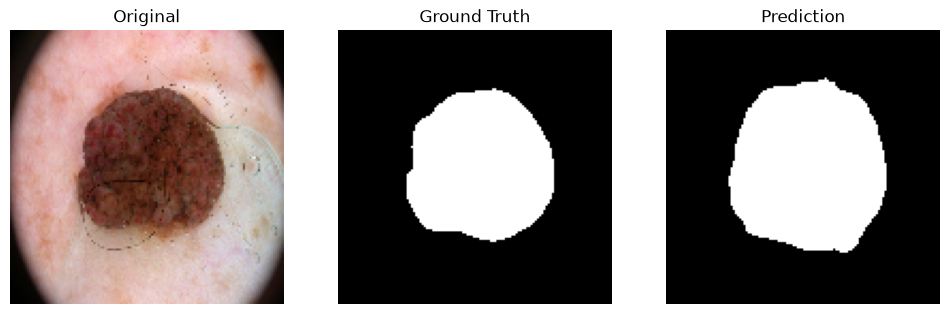

In [48]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)

plt.imshow(X_valid[0])

plt.title("Original")

plt.axis("off")

plt.subplot(1,3,2)

plt.imshow(y_valid[0].squeeze(), cmap="gray")

plt.title("Ground Truth")

plt.axis("off")

plt.subplot(1,3,3)

plt.imshow(prediction[0].squeeze(), cmap="gray")

plt.title("Prediction")

plt.axis("off")

plt.show()


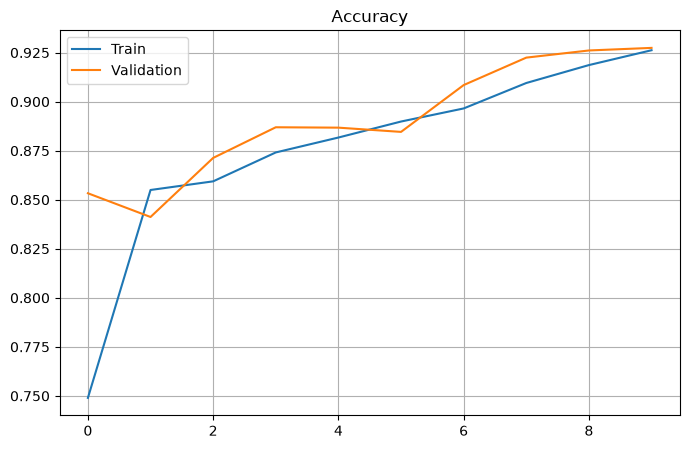

In [49]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")

plt.plot(history.history["val_accuracy"], label="Validation")

plt.legend()

plt.grid()

plt.title("Accuracy")

plt.show()


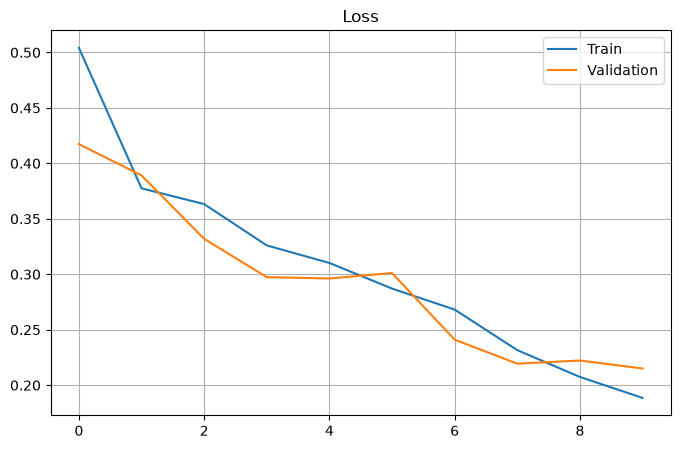

In [50]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train")

plt.plot(history.history["val_loss"], label="Validation")

plt.legend()

plt.grid()

plt.title("Loss")

plt.show()

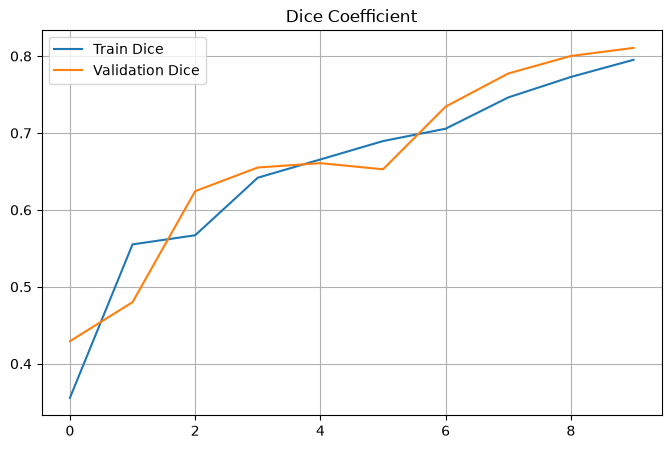

In [51]:
plt.figure(figsize=(8,5))

plt.plot(history.history["dice_coefficient"], label="Train Dice")

plt.plot(history.history["val_dice_coefficient"], label="Validation Dice")

plt.legend()

plt.grid()

plt.title("Dice Coefficient")

plt.show()

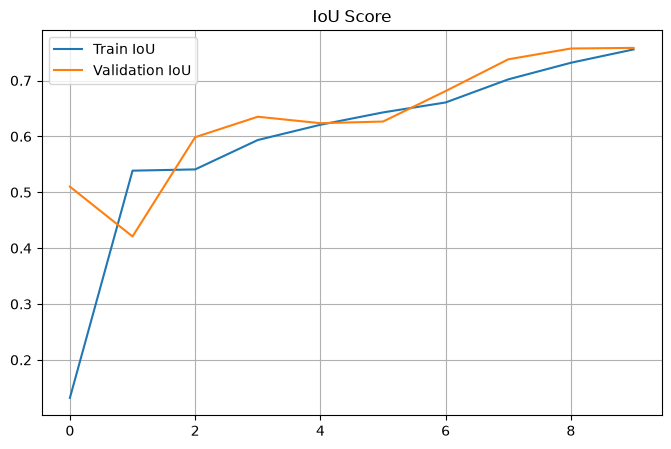

In [54]:
plt.figure(figsize=(8,5))

plt.plot(history.history["iou_score"], label="Train IoU")

plt.plot(history.history["val_iou_score"], label="Validation IoU")

plt.legend()

plt.grid()

plt.title("IoU Score")
plt.show()


In [55]:
print("\n")
print("="*70)
print("Business Insights")
print("="*70)

print("- U-Net performs pixel-wise segmentation.")

print("- Skip connections preserve spatial information.")

print("- Dice Score is the primary metric in medical segmentation.")

print("- IoU measures overlap between prediction and ground truth.")

print("- Lightweight U-Net is suitable for CPU training.")




Business Insights
- U-Net performs pixel-wise segmentation.
- Skip connections preserve spatial information.
- Dice Score is the primary metric in medical segmentation.
- IoU measures overlap between prediction and ground truth.
- Lightweight U-Net is suitable for CPU training.


In [56]:
print("\n")
print("="*70)
print("Lightweight U-Net Summary")
print("="*70)

print("Model : Lightweight U-Net")

print("Task : Binary Image Segmentation")

print("Image Size : 128 x 128")

print("Batch Size : 8")

print("Epochs : 10")

print("Optimizer : Adam")

print("Loss : Binary Crossentropy")

print("Accuracy :", round(results[1],4))

print("Dice :", round(results[2],4))

print("IoU :", round(results[3],4))

print("="*70)

print("\n")





Lightweight U-Net Summary
Model : Lightweight U-Net
Task : Binary Image Segmentation
Image Size : 128 x 128
Batch Size : 8
Epochs : 10
Optimizer : Adam
Loss : Binary Crossentropy
Accuracy : 0.9274
Dice : 0.8107
IoU : 0.7584




In [57]:
import os

import cv2

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import load_model

In [58]:
def dice_coefficient(y_true, y_pred):

    smooth = 1e-6

    y_true = tf.keras.backend.flatten(y_true)

    y_pred = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true * y_pred)

    return (2. * intersection + smooth) / (

        tf.reduce_sum(y_true) +

        tf.reduce_sum(y_pred) +

        smooth

    )

def iou_score(y_true, y_pred):

    y_pred = tf.cast(

        y_pred > 0.5,

        tf.float32

    )

    intersection = tf.reduce_sum(

        y_true * y_pred

    )

    union = (

        tf.reduce_sum(y_true)

        + tf.reduce_sum(y_pred)

        - intersection

    )

    return (

        intersection + 1e-6

    ) / (

        union + 1e-6

    )


In [59]:
loaded_model = load_model(

    "best_unet_model.keras",

    custom_objects={

        "dice_coefficient":dice_coefficient,

        "iou_score":iou_score

    }

)

print("\n")

print("="*70)

print("Lightweight U-Net Loaded Successfully")

print("="*70)




Lightweight U-Net Loaded Successfully


In [60]:
sample_image = X_valid[0]

prediction = loaded_model.predict(

    np.expand_dims(

        sample_image,

        axis=0

    ),

    verbose=0

)

prediction = (

    prediction > 0.5

).astype(np.uint8)

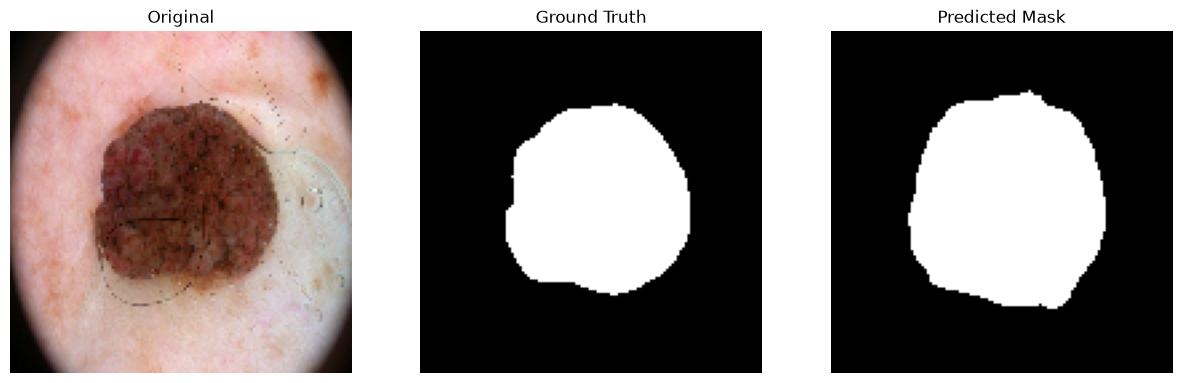

In [61]:
plt.figure(

    figsize=(15,5)

)

plt.subplot(

    1,

    3,

    1

)

plt.imshow(

    sample_image

)

plt.title("Original")

plt.axis("off")

plt.subplot(

    1,

    3,

    2

)

plt.imshow(

    y_valid[0].squeeze(),

    cmap="gray"

)

plt.title("Ground Truth")

plt.axis("off")

plt.subplot(

    1,

    3,

    3

)

plt.imshow(

    prediction[0].squeeze(),

    cmap="gray"

)

plt.title("Predicted Mask")

plt.axis("off")

plt.show()


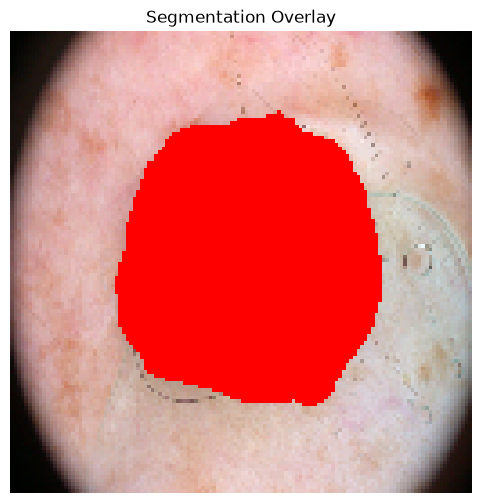

In [62]:
overlay = sample_image.copy()

mask = prediction[0].squeeze()

overlay[mask == 1] = [1,0,0]

plt.figure(

    figsize=(6,6)

)

plt.imshow(

    overlay

)

plt.title(

    "Segmentation Overlay"

)

plt.axis("off")

plt.show()


In [63]:
prediction_results = []

for i in range(

    min(

        10,

        len(X_valid)

    )

):

    pred = loaded_model.predict(

        np.expand_dims(

            X_valid[i],

            axis=0

        ),

        verbose=0

    )

    pred = (

        pred > 0.5

    ).astype(np.uint8)

    lesion_pixels = np.sum(pred)

    prediction_results.append({

        "Image No":i+1,

        "Lesion Pixels":int(

            lesion_pixels

        )

    })

prediction_df = pd.DataFrame(

    prediction_results

)

print("\n")

print("="*70)

print("Prediction Results")

print("="*70)

display(

    prediction_df

)




Prediction Results


,Image No,Lesion Pixels
0,1,4738
1,2,985
2,3,4002
3,4,3273
4,5,6445
5,6,6432
6,7,8686
7,8,5475
8,9,3362
9,10,2838


In [64]:
prediction_df.to_csv(

    "Segmentation_Predictions.csv",

    index=False

)

print("\n")

print("="*70)

print("Prediction Results Saved")




Prediction Results Saved


In [65]:
evaluation_metrics = pd.DataFrame({

    "Metric":[

        "Loss",

        "Accuracy",

        "Dice Score",

        "IoU"

    ],

    "Value":[

        results[0],

        results[1],

        results[2],

        results[3]

    ]

})

evaluation_metrics.to_csv(

    "Evaluation_Metrics.csv",

    index=False

)

display(

    evaluation_metrics

)


,Metric,Value
0,Loss,0.215063
1,Accuracy,0.927425
2,Dice Score,0.810706
3,IoU,0.758418


In [66]:
history_df = pd.DataFrame(

    history.history

)

history_df.to_csv(

    "Training_History.csv",

    index=False

)

print("\n")

print("="*70)

print("Training History Saved")

print("="*70)



Training History Saved


In [67]:
deployment = pd.DataFrame({

    "File":[

        "U-Net Model",

        "Predictions",

        "Evaluation",

        "Training History"

    ],

    "Saved As":[

        "best_unet_model.keras",

        "Segmentation_Predictions.csv",

        "Evaluation_Metrics.csv",

        "Training_History.csv"

    ]

})

print("\n")

print("="*70)

print("Deployment Summary")

print("="*70)

display(

    deployment

)




Deployment Summary


,File,Saved As
0,U-Net Model,best_unet_model.keras
1,Predictions,Segmentation_Predictions.csv
2,Evaluation,Evaluation_Metrics.csv
3,Training History,Training_History.csv


In [68]:
print("\n")

print("="*70)

print("Business Insights")

print("="*70)

print("- U-Net predicts lesion boundaries pixel-by-pixel.")

print("- Dice Score is the primary evaluation metric.")

print("- IoU measures segmentation overlap.")

print("- Skip connections preserve fine image details.")

print("- Lightweight U-Net enables efficient CPU training.")

print("- Segmentation assists clinicians in identifying lesion regions.")




Business Insights
- U-Net predicts lesion boundaries pixel-by-pixel.
- Dice Score is the primary evaluation metric.
- IoU measures segmentation overlap.
- Skip connections preserve fine image details.
- Lightweight U-Net enables efficient CPU training.
- Segmentation assists clinicians in identifying lesion regions.


In [69]:
print("\n")

print("="*70)

print("Medical Image Segmentation using Lightweight U-Net")

print("="*70)

print("Dataset                 : ISIC 2016")

print("Problem Type            : Binary Segmentation")

print("Architecture            : Lightweight U-Net")

print("Image Size              : 128 x 128")

print("Batch Size              : 8")

print("Epochs                  : 10")

print("Optimizer               : Adam")

print("Loss Function           : Binary Crossentropy")

print("Accuracy                :", round(results[1],4))

print("Dice Score              :", round(results[2],4))

print("IoU Score               :", round(results[3],4))

print("Model Saved             : best_unet_model.keras")

print("Prediction File         : Segmentation_Predictions.csv")

print("Metrics File            : Evaluation_Metrics.csv")

print("Training History File   : Training_History.csv")

print("Project Status          : Deployment Ready")

print("="*70)




Medical Image Segmentation using Lightweight U-Net
Dataset                 : ISIC 2016
Problem Type            : Binary Segmentation
Architecture            : Lightweight U-Net
Image Size              : 128 x 128
Batch Size              : 8
Epochs                  : 10
Optimizer               : Adam
Loss Function           : Binary Crossentropy
Accuracy                : 0.9274
Dice Score              : 0.8107
IoU Score               : 0.7584
Model Saved             : best_unet_model.keras
Prediction File         : Segmentation_Predictions.csv
Metrics File            : Evaluation_Metrics.csv
Training History File   : Training_History.csv
Project Status          : Deployment Ready


In [70]:
print("\n")

print("="*70)

print("Medical Image Segmentation using Lightweight U-Net")

print("Completed Successfully!")

print("="*70)



Medical Image Segmentation using Lightweight U-Net
Completed Successfully!
